In [51]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [52]:
import nltk

In [53]:
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
from nltk.sentiment import SentimentIntensityAnalyzer

VADER

In [55]:
sla=SentimentIntensityAnalyzer()
review="its the best of all such the products"
sentiment_results=sla.polarity_scores(review)
print(sentiment_results)

{'neg': 0.0, 'neu': 0.625, 'pos': 0.375, 'compound': 0.6369}


#SENTIMENT ANALYSIS USING ML+NLTK
in supervised ml,we use past data to loan patternsin the training phase and predict unseen future data.
before training the model,we'veto preprocess the text

In [56]:
from nltk.corpus import movie_reviews,stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

In [57]:
stop_words=stopwords.words('english')
lemmatizer=WordNetLemmatizer()

In [58]:
def preprocess(text):
    text=text.lower()
    text=re.sub(r'[^a-z\s]','',text)
    tokens=word_tokenize(text)
    tokens={token for token in tokens if token not in stop_words}
    lemmatizer_tokens=[lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(lemmatizer_tokens)

In [59]:
preprocess("its the best of all")

'best'

#explore the data

In [60]:
movie_reviews.fileids()

['neg/cv000_29416.txt',
 'neg/cv001_19502.txt',
 'neg/cv002_17424.txt',
 'neg/cv003_12683.txt',
 'neg/cv004_12641.txt',
 'neg/cv005_29357.txt',
 'neg/cv006_17022.txt',
 'neg/cv007_4992.txt',
 'neg/cv008_29326.txt',
 'neg/cv009_29417.txt',
 'neg/cv010_29063.txt',
 'neg/cv011_13044.txt',
 'neg/cv012_29411.txt',
 'neg/cv013_10494.txt',
 'neg/cv014_15600.txt',
 'neg/cv015_29356.txt',
 'neg/cv016_4348.txt',
 'neg/cv017_23487.txt',
 'neg/cv018_21672.txt',
 'neg/cv019_16117.txt',
 'neg/cv020_9234.txt',
 'neg/cv021_17313.txt',
 'neg/cv022_14227.txt',
 'neg/cv023_13847.txt',
 'neg/cv024_7033.txt',
 'neg/cv025_29825.txt',
 'neg/cv026_29229.txt',
 'neg/cv027_26270.txt',
 'neg/cv028_26964.txt',
 'neg/cv029_19943.txt',
 'neg/cv030_22893.txt',
 'neg/cv031_19540.txt',
 'neg/cv032_23718.txt',
 'neg/cv033_25680.txt',
 'neg/cv034_29446.txt',
 'neg/cv035_3343.txt',
 'neg/cv036_18385.txt',
 'neg/cv037_19798.txt',
 'neg/cv038_9781.txt',
 'neg/cv039_5963.txt',
 'neg/cv040_8829.txt',
 'neg/cv041_22364.txt',


In [61]:
len(movie_reviews.fileids())

2000

In [62]:
movie_reviews.fileids('pos')

['pos/cv000_29590.txt',
 'pos/cv001_18431.txt',
 'pos/cv002_15918.txt',
 'pos/cv003_11664.txt',
 'pos/cv004_11636.txt',
 'pos/cv005_29443.txt',
 'pos/cv006_15448.txt',
 'pos/cv007_4968.txt',
 'pos/cv008_29435.txt',
 'pos/cv009_29592.txt',
 'pos/cv010_29198.txt',
 'pos/cv011_12166.txt',
 'pos/cv012_29576.txt',
 'pos/cv013_10159.txt',
 'pos/cv014_13924.txt',
 'pos/cv015_29439.txt',
 'pos/cv016_4659.txt',
 'pos/cv017_22464.txt',
 'pos/cv018_20137.txt',
 'pos/cv019_14482.txt',
 'pos/cv020_8825.txt',
 'pos/cv021_15838.txt',
 'pos/cv022_12864.txt',
 'pos/cv023_12672.txt',
 'pos/cv024_6778.txt',
 'pos/cv025_3108.txt',
 'pos/cv026_29325.txt',
 'pos/cv027_25219.txt',
 'pos/cv028_26746.txt',
 'pos/cv029_18643.txt',
 'pos/cv030_21593.txt',
 'pos/cv031_18452.txt',
 'pos/cv032_22550.txt',
 'pos/cv033_24444.txt',
 'pos/cv034_29647.txt',
 'pos/cv035_3954.txt',
 'pos/cv036_16831.txt',
 'pos/cv037_18510.txt',
 'pos/cv038_9749.txt',
 'pos/cv039_6170.txt',
 'pos/cv040_8276.txt',
 'pos/cv041_21113.txt',
 

In [63]:
len(movie_reviews.fileids('pos'))

1000

In [64]:
len(movie_reviews.fileids('neg'))

1000

##extract  the first positive review and vieww(it using the row()method in movies_reviews


In [65]:
first_pos_rev=movie_reviews.fileids('pos')[0]
first_pos_rev

'pos/cv000_29590.txt'

In [66]:
pos_review=movie_reviews.raw(first_pos_rev)
pos_review

'films adapted from comic books have had plenty of success , whether they\'re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there\'s never really been a comic book like from hell before . \nfor starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid \'80s with a 12-part series called the watchmen . \nto say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . \nthe book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . \nin other words , don\'t dismiss this film because of its source . \nif you can get past the whole comic book thing , you might find another stumbling block in from hell\'s directors , albert and allen hughes . \ngetting the hughes brothers to direct this seem

In [67]:
preprocess(pos_review)

'hell ghost arthouse creepy brought song indian odd kelly anyone jackson seems page getting prophetic deming profession tim abberline starter cinematographer brother another strong violence whistling frederick befriends direct original stiff try rafael dalmatian limit actually capture design drug richardson place comparison secret created surgical gruesome mysterious ludicrous mid half researched jack mouth theyre case film find unfortunate success steve see committing deftly one vertical almost victorianera like there unsuccessfully ending ii marilyn ghetto helped whitechapel theory job novel menace peak precision part star thing little book back log language johnny think starting albert could hell scene pale ghastly casper hayes crazy completely finished allen whole much great anything surprise unique level hidden behind plenty director reason electric campbell wont graphic worry oscar subject funny need bad block nervous street dismiss joe casting particular look peter saw typically

In [68]:
first_neg_rev=movie_reviews.fileids('neg')[0]
first_neg_rev
neg_review=movie_reviews.raw(first_neg_rev)
neg_review

'plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience membe

In [69]:
x=[1,2]
y=[1,2,3,4,5,6]
for i in x:
  for j in y:
    print(i)
    print(j)

1
1
1
2
1
3
1
4
1
5
1
6
2
1
2
2
2
3
2
4
2
5
2
6


In [70]:
x= movie_reviews.categories()

reviews=[]
labels=[]
for i in x:
  for j in movie_reviews.fileids(i):
    text = movie_reviews.raw(j)
    reviews.append(text)
    labels.append(i)

In [71]:
categories =  movie_reviews.categories()
reviews=[]
labels=[]
for category in categories:
  for file in movie_reviews.fileids(category):
    raw_text=movie_reviews.raw(file)
    cleaned_text=preprocess(raw_text)
    reviews.append(raw_text)
    labels.append(category)

In [72]:
reviews[:2]

['plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience memb

In [73]:
labels[:2]

['neg', 'neg']

#train-test split

In [74]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(reviews,labels,test_size=0.25,stratify=labels)

print(f"Shape of X_train: {len(X_train)}")
print(f"Shape of X_test: {len(X_test)}")
print(f"Shape of y_train: {len(y_train)}")
print(f"Shape of y_test: {len(y_test)}")

Shape of X_train: 1500
Shape of X_test: 500
Shape of y_train: 1500
Shape of y_test: 500


##feature extraction using tf-idf


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [76]:
vectorizer=TfidfVectorizer(max_features=1000)


In [77]:
X_train_transformed=vectorizer.fit_transform(X_train)
X_test_transformed=vectorizer.transform(X_test)

In [78]:
vectorizer.get_feature_names_out()

array(['10', 'able', 'about', 'above', 'absolutely', 'across', 'act',
       'acting', 'action', 'actor', 'actors', 'actress', 'actually',
       'add', 'after', 'again', 'against', 'age', 'agent', 'ago', 'air',
       'alien', 'aliens', 'all', 'allen', 'almost', 'alone', 'along',
       'already', 'also', 'although', 'always', 'am', 'amazing',
       'america', 'american', 'among', 'an', 'and', 'animated',
       'animation', 'annoying', 'another', 'any', 'anyone', 'anything',
       'anyway', 'apparently', 'appear', 'appears', 'approach', 'are',
       'aren', 'army', 'around', 'art', 'as', 'at', 'atmosphere',
       'attempt', 'attempts', 'attention', 'audience', 'audiences',
       'away', 'baby', 'back', 'bad', 'based', 'basically', 'batman',
       'battle', 'be', 'beautiful', 'because', 'become', 'becomes',
       'been', 'before', 'begin', 'beginning', 'begins', 'behind',
       'being', 'believe', 'ben', 'best', 'better', 'between', 'beyond',
       'big', 'biggest', 'bill', '

In [79]:
X_train_transformed.shape

(1500, 1000)

In [80]:
X_test_transformed.shape

(500, 1000)

In [81]:
from sklearn.naive_bayes import MultinomialNB
mnb=MultinomialNB()
mnb.fit(X_train_transformed,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [82]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
y_pred = mnb.predict(X_test_transformed)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:4f}")
report = classification_report(y_test,y_pred)
print("classification report:")
print(report)
cm=confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(cm)

Accuracy:0.784000
classification report:
              precision    recall  f1-score   support

         neg       0.78      0.79      0.79       250
         pos       0.79      0.78      0.78       250

    accuracy                           0.78       500
   macro avg       0.78      0.78      0.78       500
weighted avg       0.78      0.78      0.78       500

confusion matrix:
[[198  52]
 [ 56 194]]


## Logistic Regression Model

In [83]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_transformed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [84]:
# Predict on the test set
y_pred_log_reg = log_reg.predict(X_test_transformed)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
report_log_reg = classification_report(y_test, y_pred_log_reg)
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print("\nLogistic Regression Classification Report:")
print(report_log_reg)
print("\nLogistic Regression Confusion Matrix:")
print(cm_log_reg)

Logistic Regression Accuracy: 0.8000

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         neg       0.80      0.80      0.80       250
         pos       0.80      0.80      0.80       250

    accuracy                           0.80       500
   macro avg       0.80      0.80      0.80       500
weighted avg       0.80      0.80      0.80       500


Logistic Regression Confusion Matrix:
[[199  51]
 [ 49 201]]


In [85]:
print("Logistic Regression Confusion Matrix:")
print(cm_log_reg)

Logistic Regression Confusion Matrix:
[[199  51]
 [ 49 201]]


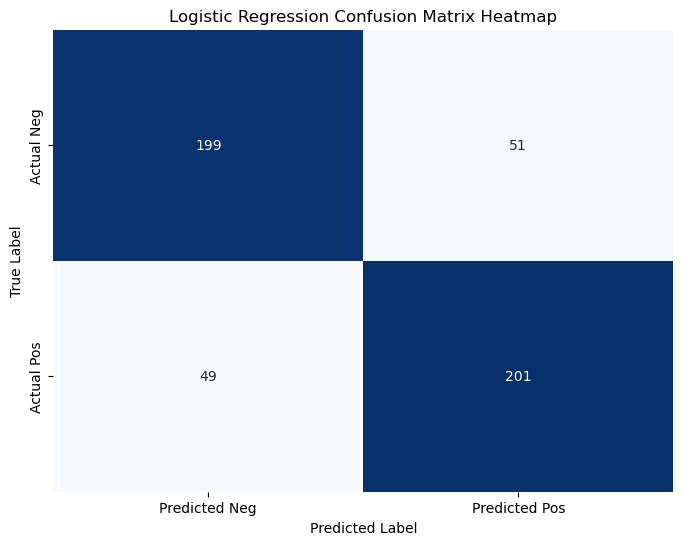

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap for the Logistic Regression Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Logistic Regression Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

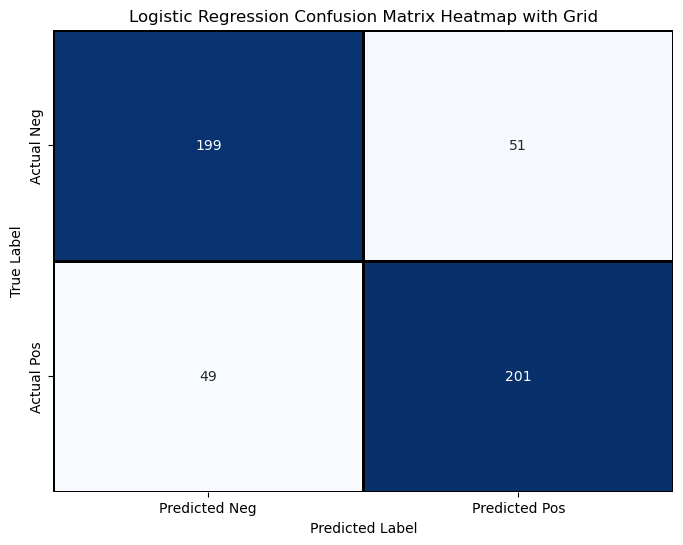

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap for the Logistic Regression Confusion Matrix with grid lines
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            linecolor='black', linewidths=1) # Added linecolor and linewidths for grid
plt.title('Logistic Regression Confusion Matrix Heatmap with Grid')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Comparing Confusion Matrices

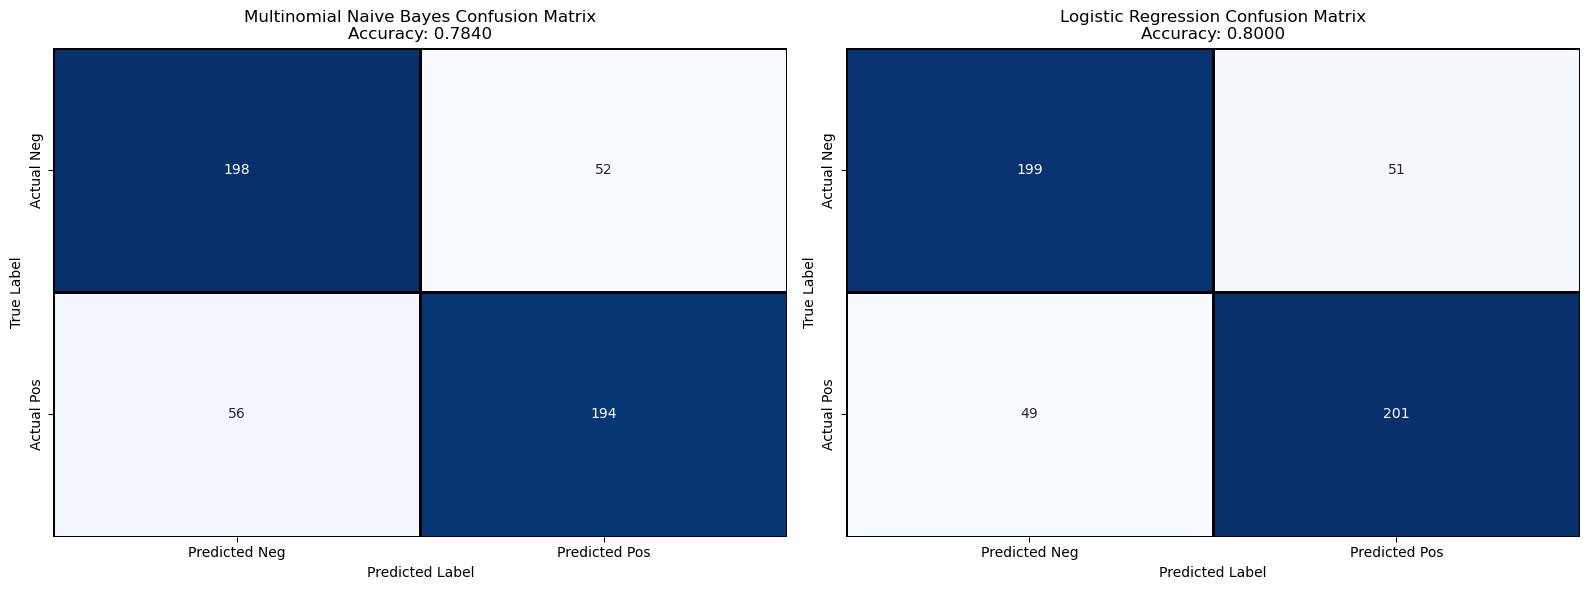

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Multinomial Naive Bayes Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            linecolor='black', linewidths=1, ax=axes[0])
axes[0].set_title(f'Multinomial Naive Bayes Confusion Matrix\nAccuracy: {accuracy:.4f}')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot for Logistic Regression Confusion Matrix
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            linecolor='black', linewidths=1, ax=axes[1])
axes[1].set_title(f'Logistic Regression Confusion Matrix\nAccuracy: {accuracy_log_reg:.4f}')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [89]:
plt.show()

In [90]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [91]:
import joblib

In [92]:
joblib.dump(mnb,'model.joblib')

['model.joblib']

In [93]:
joblib.dump(vectorizer,'tf_idf.joblib')

['tf_idf.joblib']

In [94]:
load_model=joblib.load("model.joblib")

In [95]:
tf_idf=joblib.load("tf_idf.joblib")

In [96]:
review="the movie was boring and uninteresting!!!"

In [97]:
cleaned_review=preprocess(review)
cleaned_review

'uninteresting movie boring'

In [98]:
features=tf_idf.transform([cleaned_review])
features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 1000)>

In [99]:
prediction=load_model.predict(features)
prediction

array(['neg'], dtype='<U3')